In [56]:
import os
import pandas as pd
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rc_context

In [57]:
def extract_matrix_data(text):
    """
    Extract structured data from performance matrix text.
    
    Parameters:
    text (str): Text containing ARI and similarity metrics
    
    Returns:
    dict: Dictionary with extracted metrics
    """
    lines = text.strip().split('\n')
    
    # Initialize result dictionary
    result = {
        'ari': {},
        'similarity': {},
        'group_level_similarity': {}
    }
    
    for line in lines:
        line = line.strip()
        
        # Extract ARI values
        if line.startswith('ARI for '):
            parts = line.split(': ')
            if len(parts) == 2:
                method = parts[0].replace('ARI for ', '')
                value = float(parts[1])
                result['ari'][method] = value
        
        # Extract Similarity values (non-group level)
        elif line.startswith('Similarity key: ') and 'Group-level' not in line:
            parts = line.split(', ')
            if len(parts) == 2:
                key = parts[0].replace('Similarity key: ', '')
                mean_part = parts[1]
                mean_value = float(mean_part.replace('Mean: ', ''))
                result['similarity'][key] = mean_value
        
        # Extract Group-level Similarity values
        elif line.startswith('Group-level Similarity key: '):
            parts = line.split(', ')
            if len(parts) == 2:
                key = parts[0].replace('Group-level Similarity key: ', '')
                mean_part = parts[1]
                mean_value = float(mean_part.replace('Mean: ', ''))
                result['group_level_similarity'][key] = mean_value
    
    return result

In [58]:
df_list = []
dir_ = '/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets/all_add_table_benchmark/output'
for sample in ['sample2', 'sample5', 'sample8', 'sample9']:
    for method in ['table', 'notable']:
        for version in ['1', '2', '3']:
            res = os.path.join(dir_, f'{sample}_deepseek_{method}_metrics_v{version}.txt')
            # print(res)
            with open(res) as f:
                text = f.read()
            metrics = extract_matrix_data(text)
            df = pd.DataFrame(metrics['group_level_similarity'], index=[sample])
            df['sample'] = sample
            df['method'] = method
            df['version'] = version
            df_list.append(df)
        
df = pd.concat(df_list)

In [59]:
df = df.melt(id_vars=['sample', 'method', 'version'], var_name='metric', value_name='value')
df.rename(columns={'sample': 'Sample', 'method': 'method', 'metric': 'Metric', 'value': 'Group-level Accuracy'}, inplace=True)
rename_dict = {
    'similarity_scextract': 'scExtract',
    'similarity_no_context_annotation': 'scExtract (no context)',
    'similarity_gptcelltype_annotation': 'GPTCelltype'
}

df['Metric'] = df['Metric'].map(rename_dict)

/tmp/ipykernel_3424525/822146368.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  g = sns.catplot(data=df, x='Sample', y='Group-level Accuracy', hue='method', col='Metric', kind='bar', height=3.5, aspect=0.9,


<Figure size 600x300 with 0 Axes>

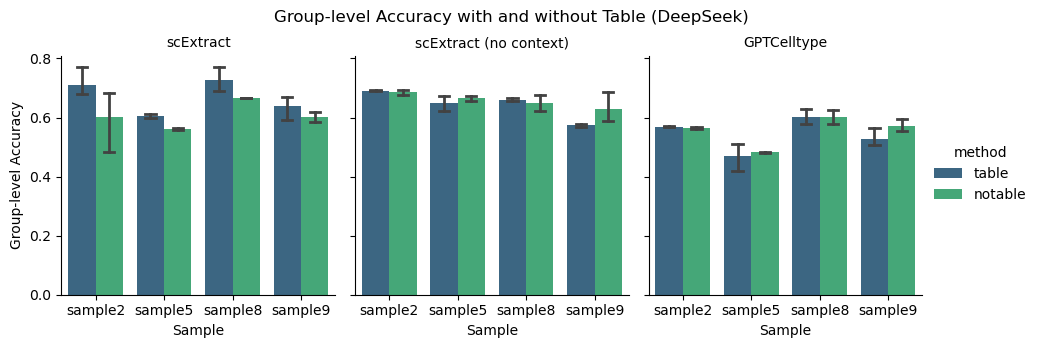

In [ ]:
with rc_context({'figure.figsize': (6, 3)}):
    g = sns.catplot(data=df, x='Sample', y='Group-level Accuracy', hue='method', col='Metric', kind='bar', height=3.5, aspect=0.9,
                palette='viridis', capsize=0.3, errwidth=2)
    g.set_titles('{col_name}')
    plt.suptitle('Group-level Accuracy with and without Table (DeepSeek)', fontsize=12)
    plt.subplots_adjust(top=0.85)
    plt.show()
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/add_sup_table/with_table_vs_no_table_group_level_accuracy_deepseek.pdf', bbox_inches='tight')

In [65]:
df_list = []
dir_ = '/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets/all_add_table_benchmark/output'
for sample in ['sample2', 'sample5', 'sample8', 'sample9']:
    for method in ['table', 'notable']:
        for version in ['1', '2', '3']:
            res = os.path.join(dir_, f'{sample}_deepseek_{method}_metrics_v{version}.txt')
            # print(res)
            with open(res) as f:
                text = f.read()
            metrics = extract_matrix_data(text)
            df = pd.DataFrame(metrics['similarity'], index=[sample])
            df['sample'] = sample
            df['method'] = method
            df['version'] = version
            df_list.append(df)
        
df = pd.concat(df_list)

In [66]:
df = df.melt(id_vars=['sample', 'method', 'version'], var_name='metric', value_name='value')
df.rename(columns={'sample': 'Sample', 'method': 'method', 'metric': 'Metric', 'value': 'Accuracy'}, inplace=True)
df['Metric'] = df['Metric'].map(rename_dict)

/tmp/ipykernel_3424525/1529619232.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  g = sns.catplot(data=df, x='Sample', y='Accuracy', hue='method', col='Metric', kind='bar', height=3.5, aspect=0.9,


<Figure size 600x300 with 0 Axes>

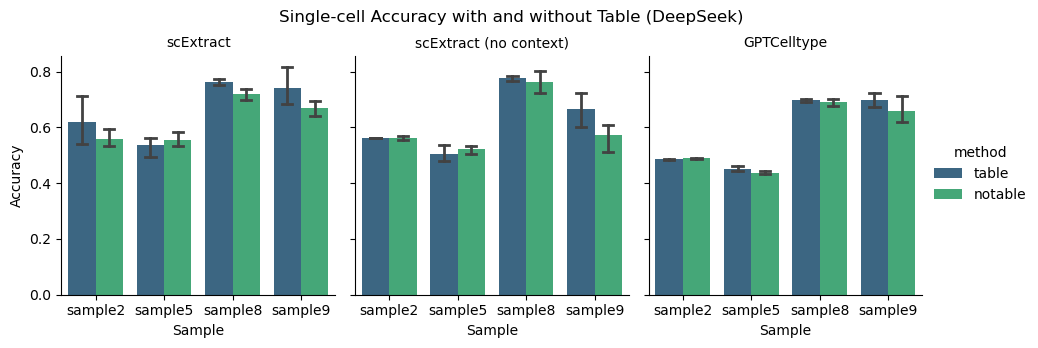

In [69]:
with rc_context({'figure.figsize': (6, 3)}):
    g = sns.catplot(data=df, x='Sample', y='Accuracy', hue='method', col='Metric', kind='bar', height=3.5, aspect=0.9,
                palette='viridis', capsize=0.3, errwidth=2)
    g.set_titles('{col_name}')
    plt.suptitle('Single-cell Accuracy with and without Table (DeepSeek)', fontsize=12)
    plt.subplots_adjust(top=0.85)
    plt.show()
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/add_sup_table/with_table_vs_no_table_accuracy_deepseek.pdf', bbox_inches='tight')

## Claude

In [70]:
df_list = []
dir_ = '/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets/all_add_table_benchmark/output'
for sample in ['sample2', 'sample5', 'sample8', 'sample9']:
    for method in ['table', 'notable']:
        for version in ['1', '2', '3']:
            res = os.path.join(dir_, f'{sample}_claude35_{method}_metrics_v{version}.txt')
            # print(res)
            with open(res) as f:
                text = f.read()
            metrics = extract_matrix_data(text)
            df = pd.DataFrame(metrics['group_level_similarity'], index=[sample])
            df['sample'] = sample
            df['method'] = method
            df['version'] = version
            df_list.append(df)
        
df = pd.concat(df_list)

In [71]:
df = df.melt(id_vars=['sample', 'method', 'version'], var_name='metric', value_name='value')
df.rename(columns={'sample': 'Sample', 'method': 'method', 'metric': 'Metric', 'value': 'Group-level Accuracy'}, inplace=True)
rename_dict = {
    'similarity_scextract': 'scExtract',
    'similarity_no_context_annotation': 'scExtract (no context)',
    'similarity_gptcelltype_annotation': 'GPTCelltype'
}

df['Metric'] = df['Metric'].map(rename_dict)

/tmp/ipykernel_3424525/383134209.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  g = sns.catplot(data=df, x='Sample', y='Group-level Accuracy', hue='method', col='Metric', kind='bar', height=3.5, aspect=0.9,


<Figure size 600x300 with 0 Axes>

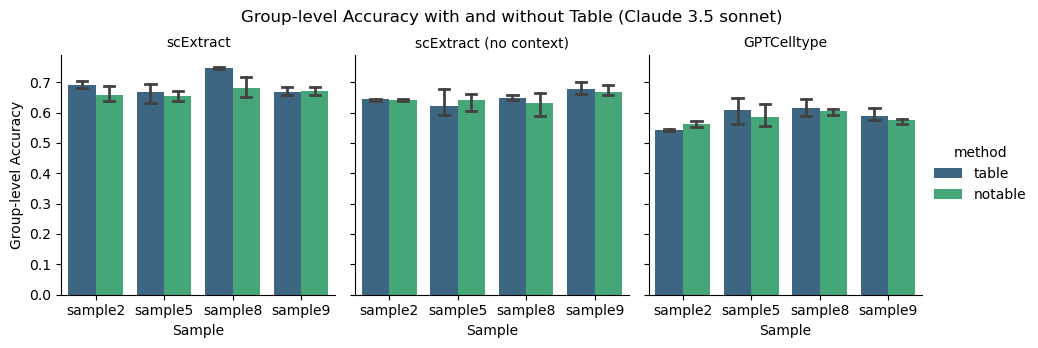

In [72]:
with rc_context({'figure.figsize': (6, 3)}):
    g = sns.catplot(data=df, x='Sample', y='Group-level Accuracy', hue='method', col='Metric', kind='bar', height=3.5, aspect=0.9,
                palette='viridis', capsize=0.3, errwidth=2)
    g.set_titles('{col_name}')
    plt.suptitle('Group-level Accuracy with and without Table (Claude 3.5 sonnet)', fontsize=12)
    plt.subplots_adjust(top=0.85)
    plt.show()
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/add_sup_table/with_table_vs_no_table_group_level_accuracy_claude.pdf', bbox_inches='tight')

In [74]:
df_list = []
dir_ = '/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets/all_add_table_benchmark/output'
for sample in ['sample2', 'sample5', 'sample8', 'sample9']:
    for method in ['table', 'notable']:
        for version in ['1', '2', '3']:
            res = os.path.join(dir_, f'{sample}_claude35_{method}_metrics_v{version}.txt')
            # print(res)
            with open(res) as f:
                text = f.read()
            metrics = extract_matrix_data(text)
            df = pd.DataFrame(metrics['similarity'], index=[sample])
            df['sample'] = sample
            df['method'] = method
            df['version'] = version
            df_list.append(df)
        
df = pd.concat(df_list)

In [75]:
df = df.melt(id_vars=['sample', 'method', 'version'], var_name='metric', value_name='value')
df.rename(columns={'sample': 'Sample', 'method': 'method', 'metric': 'Metric', 'value': 'Accuracy'}, inplace=True)
df['Metric'] = df['Metric'].map(rename_dict)

/tmp/ipykernel_3424525/230186938.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  g = sns.catplot(data=df, x='Sample', y='Accuracy', hue='method', col='Metric', kind='bar', height=3.5, aspect=0.9,


<Figure size 600x300 with 0 Axes>

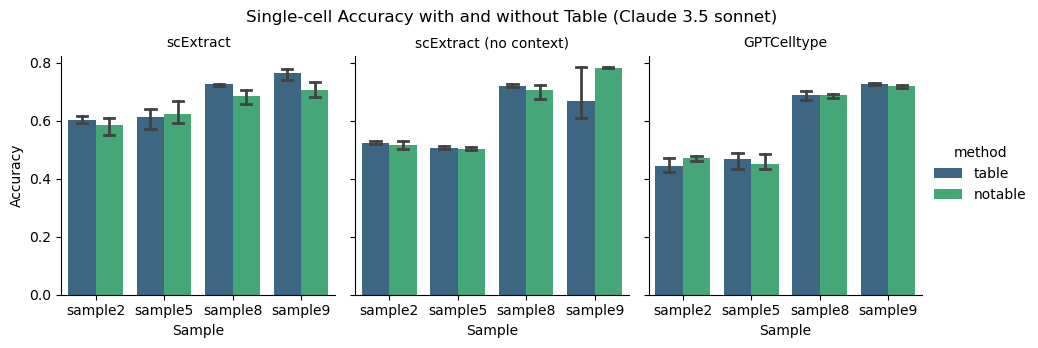

In [76]:
with rc_context({'figure.figsize': (6, 3)}):
    g = sns.catplot(data=df, x='Sample', y='Accuracy', hue='method', col='Metric', kind='bar', height=3.5, aspect=0.9,
                palette='viridis', capsize=0.3, errwidth=2)
    g.set_titles('{col_name}')
    plt.suptitle('Single-cell Accuracy with and without Table (Claude 3.5 sonnet)', fontsize=12)
    plt.subplots_adjust(top=0.85)
    plt.show()
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/add_sup_table/with_table_vs_no_table_accuracy_claude.pdf', bbox_inches='tight')